In [121]:
# packages
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

In [122]:
## Apply all the formatting

# use latex
mpl.rcParams['text.usetex'] = True

# use the paper.mplstyle file 
style_path = "paper.mplstyle"
print(f"Beginning of file {style_path}:")
with open(style_path) as f:
    lines_to_print = 8
    for i in range(lines_to_print):
        line = f.readline()
        print(line, end='')
plt.style.use(style_path)

# use journal sizing
pt = 1./72.27 # Hundreds of years of history... 72.27 points to an inch.
jour_sizes = {"PRD": {"onecol": 246.*pt, "twocol": 510.*pt},
              "CQG": {"onecol": 374.*pt}, # CQG is only one column
              # Add more journals below. Can add more properties to each journal
             }

# apply golden ratio
my_width = jour_sizes["PRD"]["twocol"]
golden = (1 + 5 ** 0.5) / 2

# dimensions for single plots
single_width = my_width/1.2
single_height = (my_width/golden)/1.2

# dimensions for double plots
double_width = my_width
double_height = (my_width/golden)*0.8

Beginning of file paper.mplstyle:
## See https://matplotlib.org/stable/tutorials/introductory/customizing.html#a-sample-matplotlibrc-file

text.usetex: True
text.latex.preamble: \usepackage{amsmath}\usepackage{amssymb}
font.family: serif
font.serif: Computer Modern
savefig.bbox: tight
savefig.format: pdf


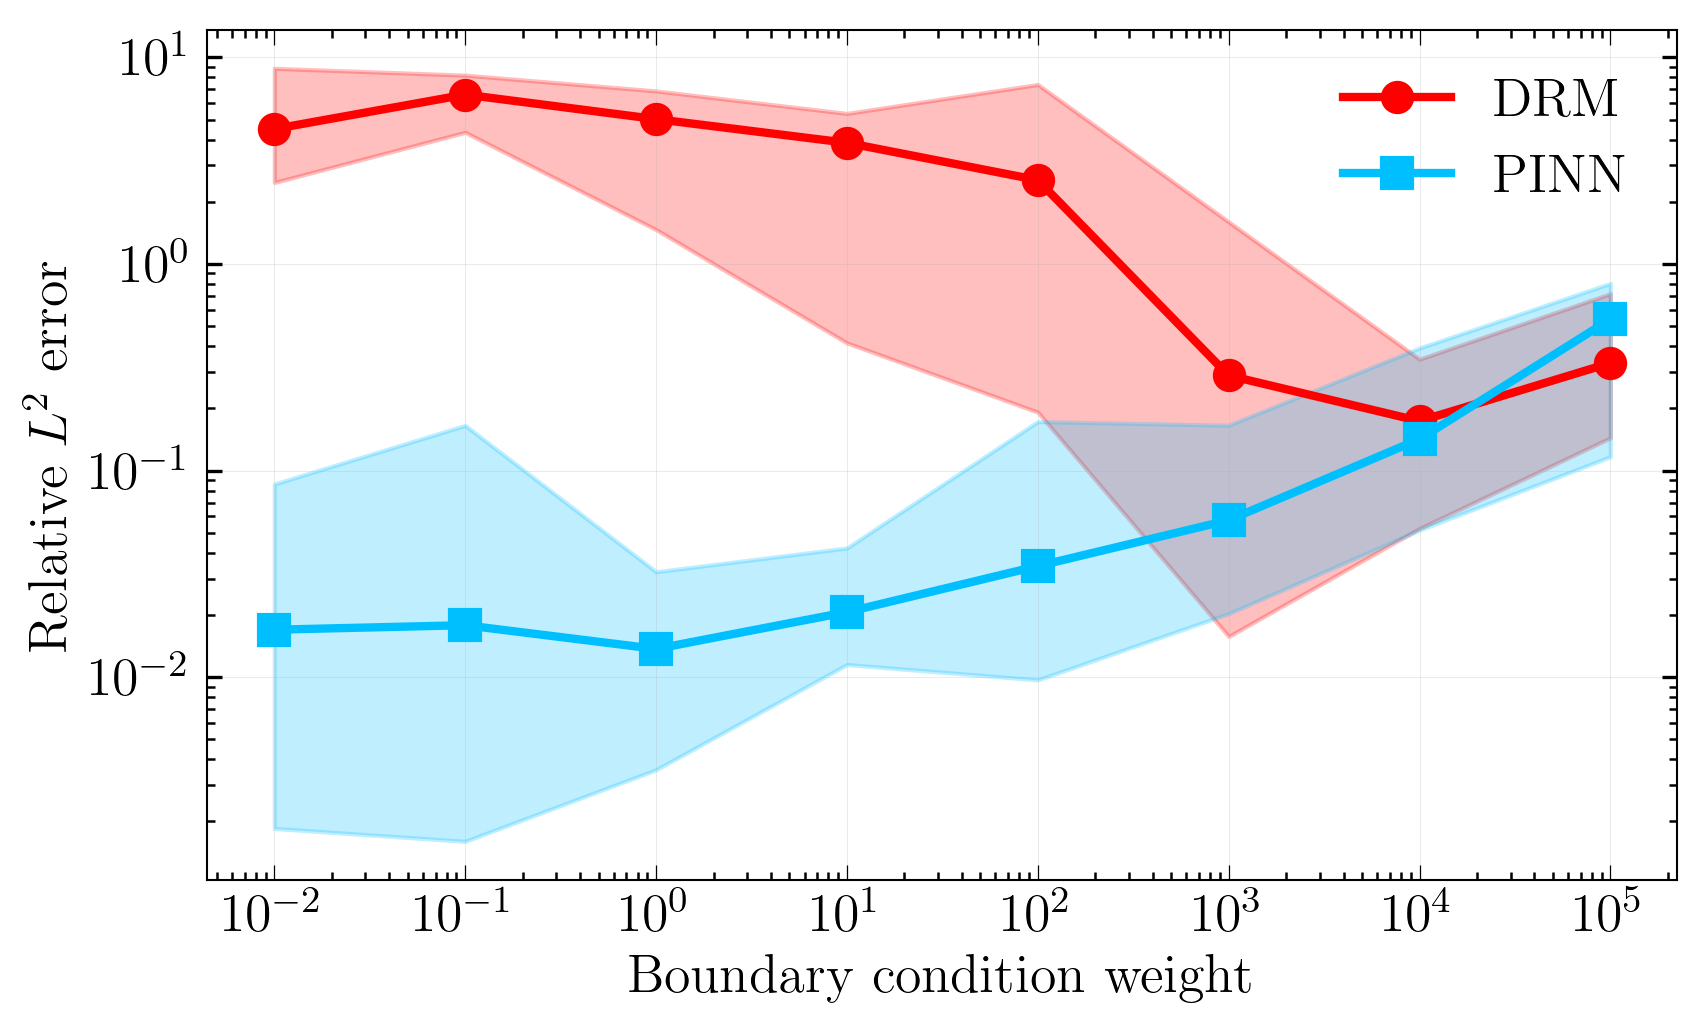

In [123]:
## BC Sweep

# manually resize the text for single plot
mpl.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
})

# Load Deep Ritz results
dr_data = np.load("deepritz_1d_bc_weight_sweep_50seeds_minmax.npz")
dr_bc_weights = dr_data["param_values"]
dr_mean_l2 = dr_data["mean_final_rel_l2_full"]
dr_l2_min = dr_data["min_final_rel_l2_full"]
dr_l2_max = dr_data["max_final_rel_l2_full"]

# Load PINNs results
pinn_data = np.load("pinn_1d_bc_weight_sweep_50seeds_minmax.npz")
pinn_bc_weights = pinn_data["param_values"]
pinn_mean_l2 = pinn_data["mean_final_rel_l2_full"]
pinn_l2_min = pinn_data["min_final_rel_l2_full"]
pinn_l2_max = pinn_data["max_final_rel_l2_full"]

# set x axis
dr_x = dr_bc_weights
pinn_x = pinn_bc_weights

# name file
filename = "bc_sweep"

# plot
fig = plt.figure(figsize=(single_width, single_height))

# data plotting
plt.plot(dr_x, dr_mean_l2, marker="o", linewidth=2, markersize=7, label="DRM", color="red")
plt.fill_between(dr_x, dr_l2_min, dr_l2_max, alpha=0.25, color="red")
plt.plot(pinn_x, pinn_mean_l2, marker="s", linewidth=2, markersize=7, label="PINN", color="deepskyblue")
plt.fill_between(pinn_x, pinn_l2_min, pinn_l2_max, alpha=0.25, color="deepskyblue")

# axis scaling
plt.xscale("log")
plt.yscale("log")

# labels
plt.xlabel("Boundary condition weight")
plt.ylabel("Relative $L^2$ error")

# formatting
plt.grid(True, which="major", alpha=0.3)
plt.legend()
plt.tight_layout()

fig.savefig(f"{filename}.png")
fig.savefig(f"{filename}.pdf")
plt.show()

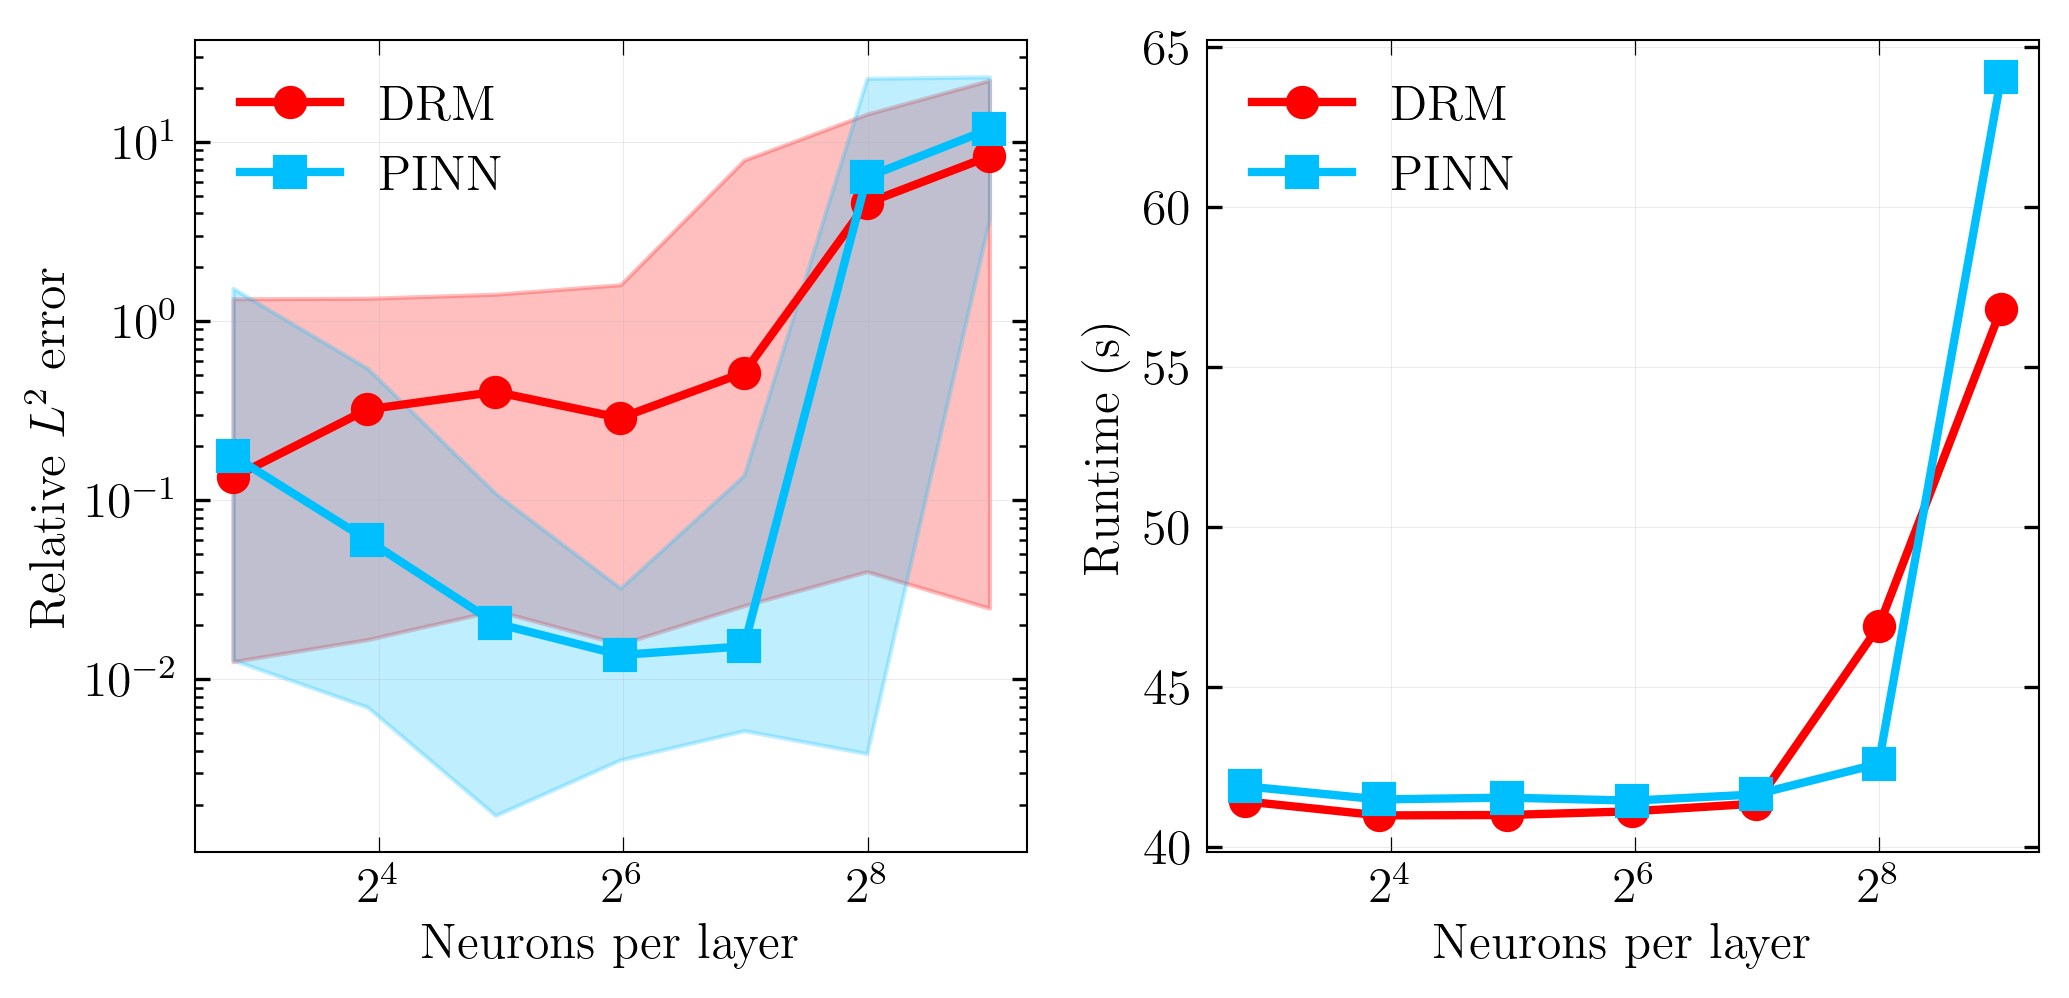

In [124]:
## Width Sweep

# manually resize the text for double plot
mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

# Load Deep Ritz results
dr_data = np.load("deepritz_1d_width_sweep_50seeds_minmax.npz")
dr_widths = dr_data["param_values"]-1
dr_mean_l2 = dr_data["mean_final_rel_l2_full"]
dr_l2_min = dr_data["min_final_rel_l2_full"]
dr_l2_max = dr_data["max_final_rel_l2_full"]
dr_rt_data = np.load("deepritz_1d_width_sweep_50seeds.npz")
dr_rt_mean = dr_rt_data["mean_runtime"]

# Load PINNs results
pinn_data = np.load("pinn_1d_width_sweep_50seeds_minmax.npz")
pinn_widths = pinn_data["param_values"]-1
pinn_mean_l2 = pinn_data["mean_final_rel_l2_full"]
pinn_l2_min = pinn_data["min_final_rel_l2_full"]
pinn_l2_max = pinn_data["max_final_rel_l2_full"]
pinn_rt_data = np.load("pinn_1d_width_sweep_50seeds.npz")
pinn_rt_mean = pinn_rt_data["mean_runtime"]

# set x axis
dr_x = dr_widths
pinn_x = pinn_widths

# name file
filename = "width_sweep"

# plot: left = relative L2, right = runtime
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(double_width, double_height))

# Left subplot: Relative L2
ax1.plot(dr_x, dr_mean_l2, marker="o", linewidth=2, markersize=7, label="DRM", color="red")
ax1.fill_between(dr_x, dr_l2_min, dr_l2_max, alpha=0.25, color="red")
ax1.plot(pinn_x, pinn_mean_l2, marker="s", linewidth=2, markersize=7, label="PINN", color="deepskyblue")
ax1.fill_between(pinn_x, pinn_l2_min, pinn_l2_max, alpha=0.25, color="deepskyblue")
ax1.set_xscale("log", base=2)
ax1.set_yscale("log")
ax1.set_xlabel("Neurons per layer")
ax1.set_ylabel("Relative $L^2$ error")
ax1.grid(True, which="major", alpha=0.3)
ax1.legend(loc="upper left")

# Right subplot: Runtime
ax2.plot(dr_x, dr_rt_mean, marker="o", linewidth=2, markersize=7, label="DRM", color="red")
ax2.plot(pinn_x, pinn_rt_mean, marker="s", linewidth=2, markersize=7, label="PINN", color="deepskyblue")
ax2.set_xscale("log", base=2)
ax2.set_xlabel("Neurons per layer")
ax2.set_ylabel("Runtime (s)")
ax2.grid(True, which="major", alpha=0.3)
ax2.legend(loc="upper left")

plt.tight_layout()

fig.savefig(f"{filename}.png")
fig.savefig(f"{filename}.pdf")
plt.show()

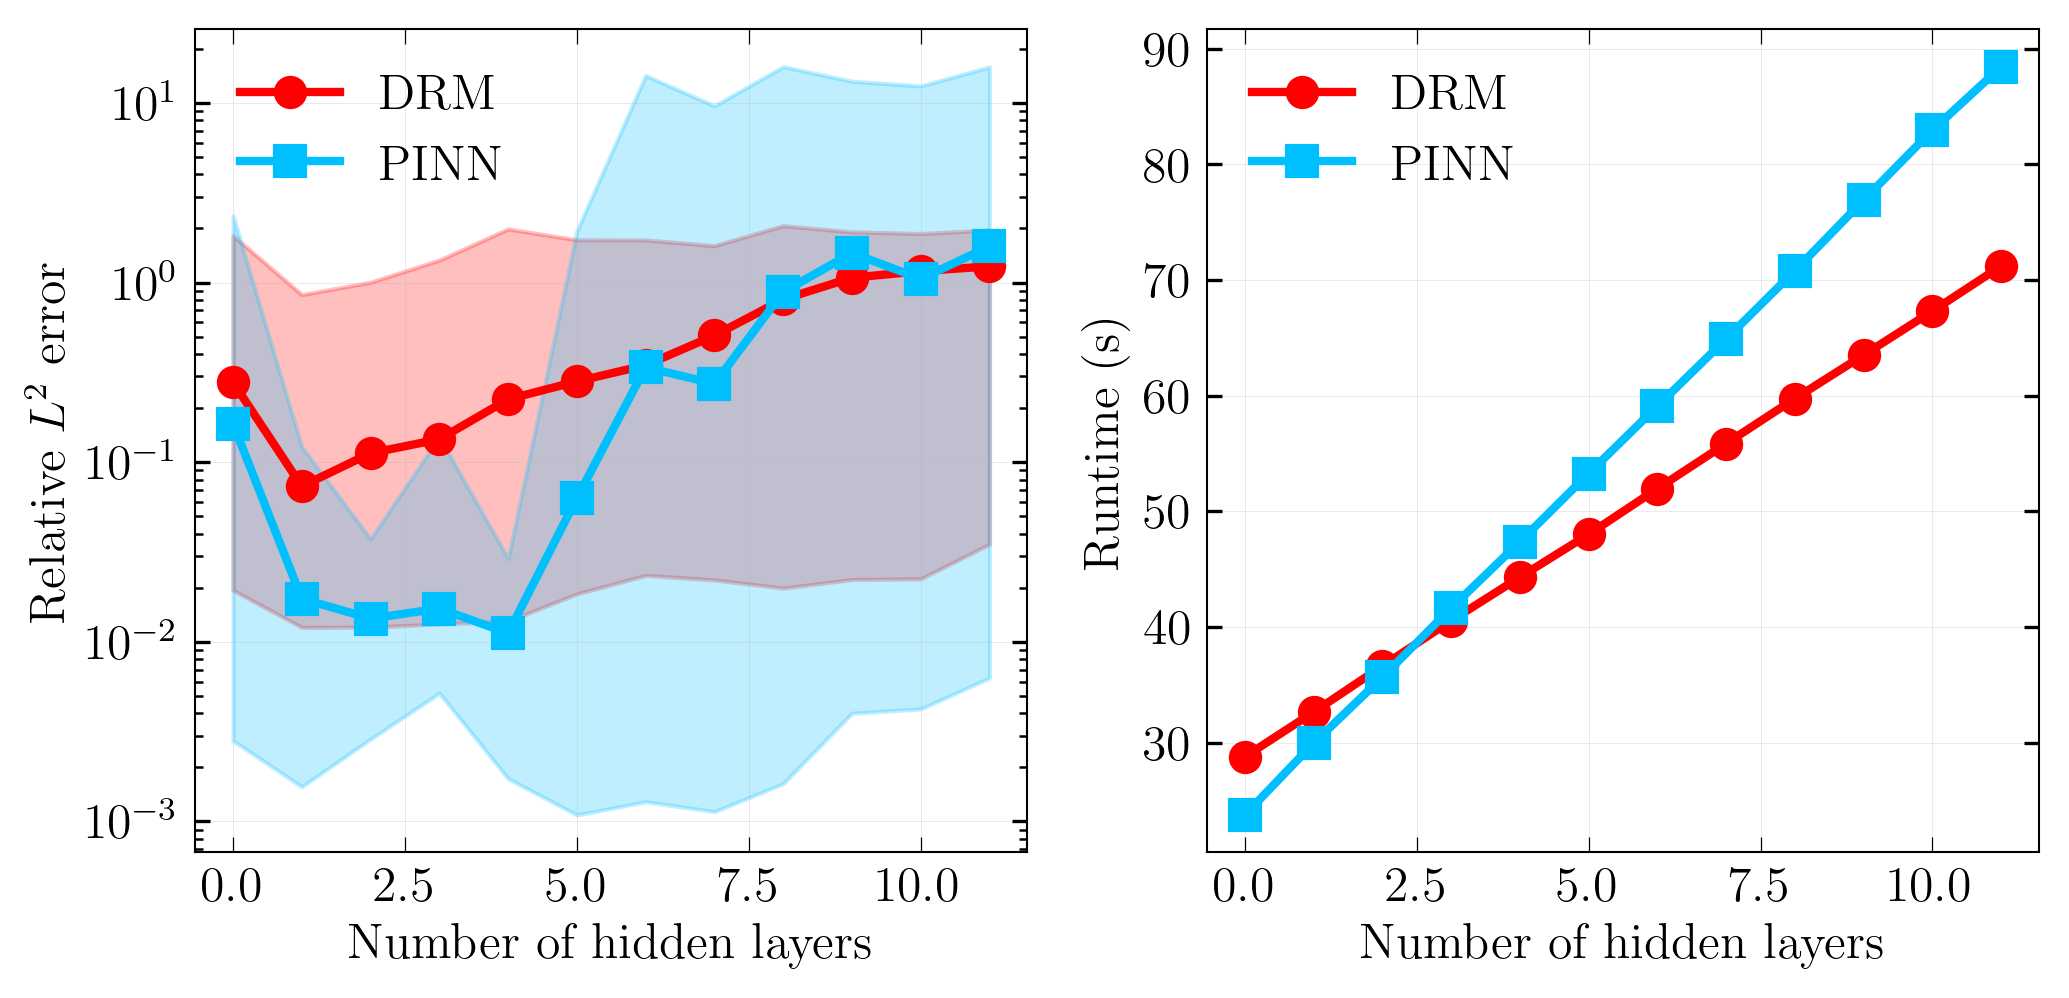

In [125]:
## Layers Sweep

# manually resize the text for double plot
mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

# Load Deep Ritz results
dr_data = np.load("deepritz_1d_layer_sweep_50seeds_minmax.npz")
dr_layers = dr_data["param_values"]-1
dr_mean_l2 = dr_data["mean_final_rel_l2_full"]
dr_l2_min = dr_data["min_final_rel_l2_full"]
dr_l2_max = dr_data["max_final_rel_l2_full"]
dr_rt_data = np.load("deepritz_1d_layer_sweep_50seeds.npz")
dr_rt_mean = dr_rt_data["mean_runtime"]

# Load PINNs results
pinn_data = np.load("pinn_1d_layer_sweep_50seeds_minmax.npz")
pinn_layers = pinn_data["param_values"]-1
pinn_mean_l2 = pinn_data["mean_final_rel_l2_full"]
pinn_l2_min = pinn_data["min_final_rel_l2_full"]
pinn_l2_max = pinn_data["max_final_rel_l2_full"]
pinn_rt_data = np.load("pinn_1d_layer_sweep_50seeds.npz")
pinn_rt_mean = pinn_rt_data["mean_runtime"]

# set x axis
dr_x = dr_layers
pinn_x = pinn_layers

# name file
filename = "layers_sweep"

# plot: left = relative L2, right = runtime
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(double_width, double_height))

# Left subplot: Relative L2
ax1.plot(dr_x, dr_mean_l2, marker="o", linewidth=2, markersize=7, label="DRM", color="red")
ax1.fill_between(dr_x, dr_l2_min, dr_l2_max, alpha=0.25, color="red")
ax1.plot(pinn_x, pinn_mean_l2, marker="s", linewidth=2, markersize=7, label="PINN", color="deepskyblue")
ax1.fill_between(pinn_x, pinn_l2_min, pinn_l2_max, alpha=0.25, color="deepskyblue")
ax1.set_yscale("log")
ax1.set_xlabel("Number of hidden layers")
ax1.set_ylabel("Relative $L^2$ error")
ax1.grid(True, which="major", alpha=0.3)
ax1.legend(loc="upper left")

# Right subplot: Runtime
ax2.plot(dr_x, dr_rt_mean, marker="o", linewidth=2, markersize=7, label="DRM", color="red")
ax2.plot(pinn_x, pinn_rt_mean, marker="s", linewidth=2, markersize=7, label="PINN", color="deepskyblue")
ax2.set_xlabel("Number of hidden layers")
ax2.set_ylabel("Runtime (s)")
ax2.grid(True, which="major", alpha=0.3)
ax2.legend(loc="upper left")

plt.tight_layout()

fig.savefig(f"{filename}.png")
fig.savefig(f"{filename}.pdf")
plt.show()

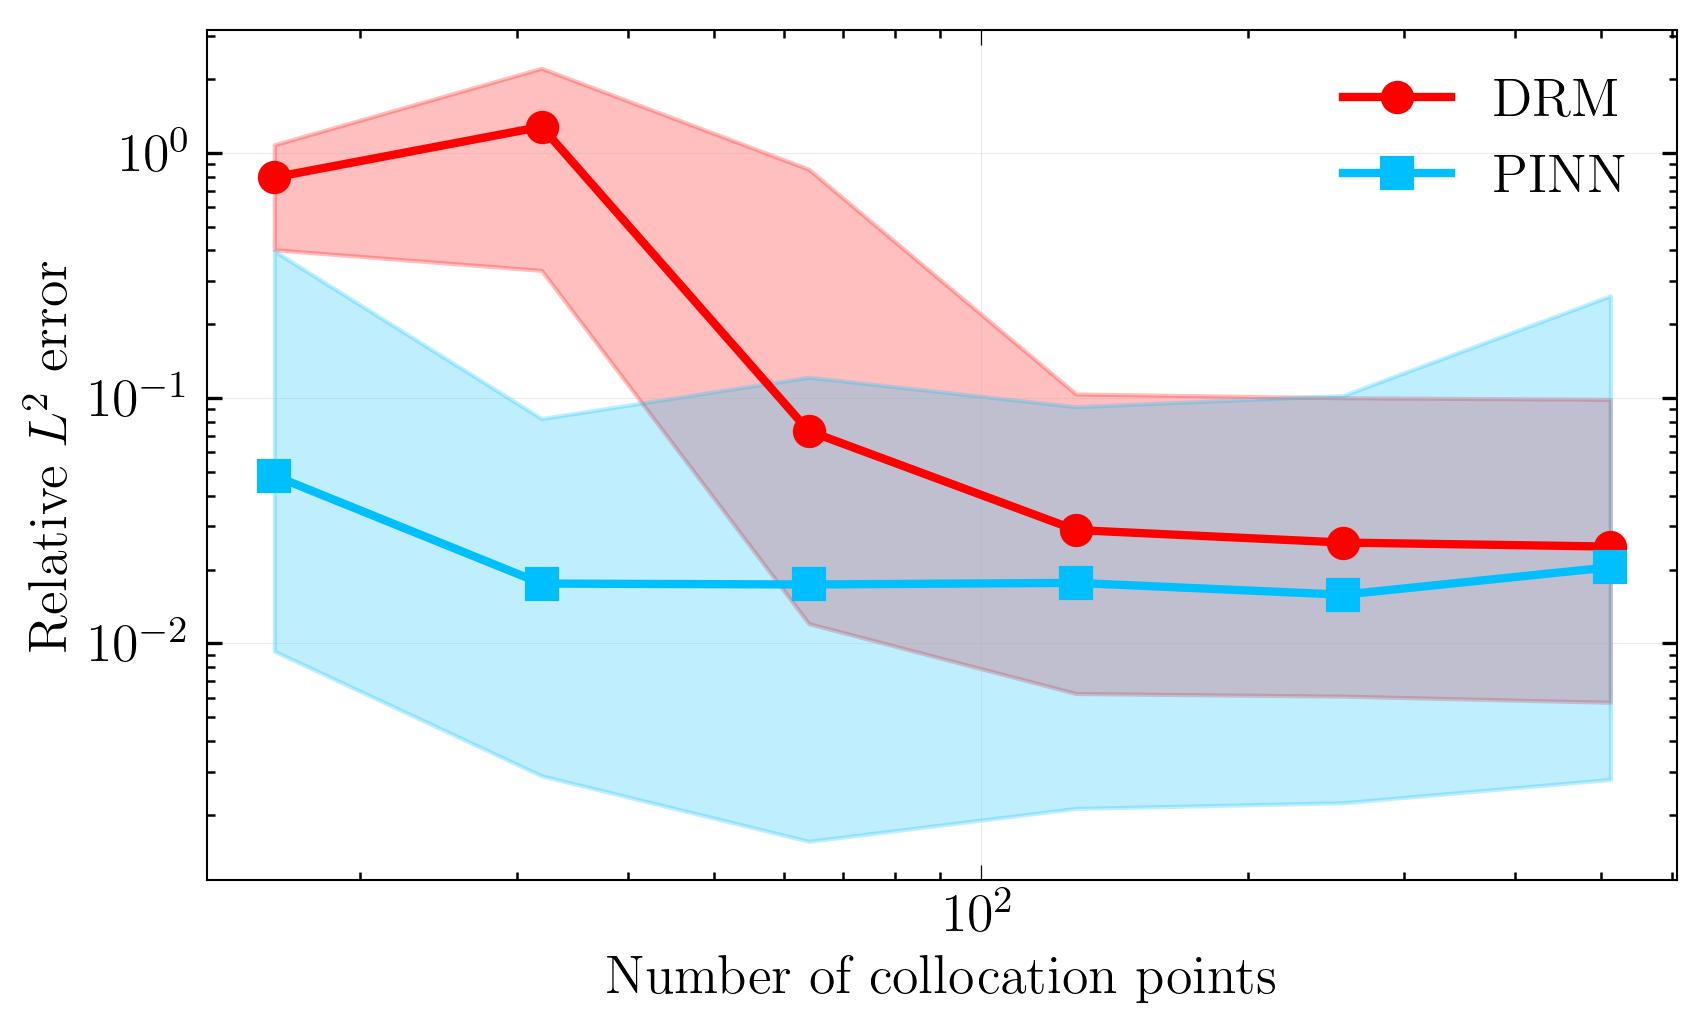

In [126]:
## Collocation Points

# manually resize the text for single plot
mpl.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
})

# Load Deep Ritz results
dr_data = np.load("deepritz_1d_collocation_sweep_50seeds_minmax.npz")
dr_collocation = dr_data["param_values"]
dr_mean_l2 = dr_data["mean_final_rel_l2_full"]
dr_l2_min = dr_data["min_final_rel_l2_full"]
dr_l2_max = dr_data["max_final_rel_l2_full"]

# Load PINNs results
pinn_data = np.load("pinn_1d_points_sweep_50seeds_minmax.npz")
pinn_collocation = pinn_data["param_values"]
pinn_mean_l2 = pinn_data["mean_final_rel_l2_full"]
pinn_l2_min = pinn_data["min_final_rel_l2_full"]
pinn_l2_max = pinn_data["max_final_rel_l2_full"]

# set x axis
dr_x = dr_collocation
pinn_x = pinn_collocation

# name file
filename = "collocation_sweep"

# plot
fig = plt.figure(figsize=(single_width, single_height))

# data plotting
plt.plot(dr_x, dr_mean_l2, marker="o", linewidth=2, markersize=7, label="DRM", color="red")
plt.fill_between(dr_x, dr_l2_min, dr_l2_max, alpha=0.25, color="red")
plt.plot(pinn_x, pinn_mean_l2, marker="s", linewidth=2, markersize=7, label="PINN", color="deepskyblue")
plt.fill_between(pinn_x, pinn_l2_min, pinn_l2_max, alpha=0.25, color="deepskyblue")

# axis scaling
plt.xscale("log")
plt.yscale("log")

# labels
plt.xlabel("Number of collocation points")
plt.ylabel("Relative $L^2$ error")

# formatting
plt.grid(True, which="major", alpha=0.3)
plt.legend()
plt.tight_layout()

fig.savefig(f"{filename}.png")
fig.savefig(f"{filename}.pdf")
plt.show()

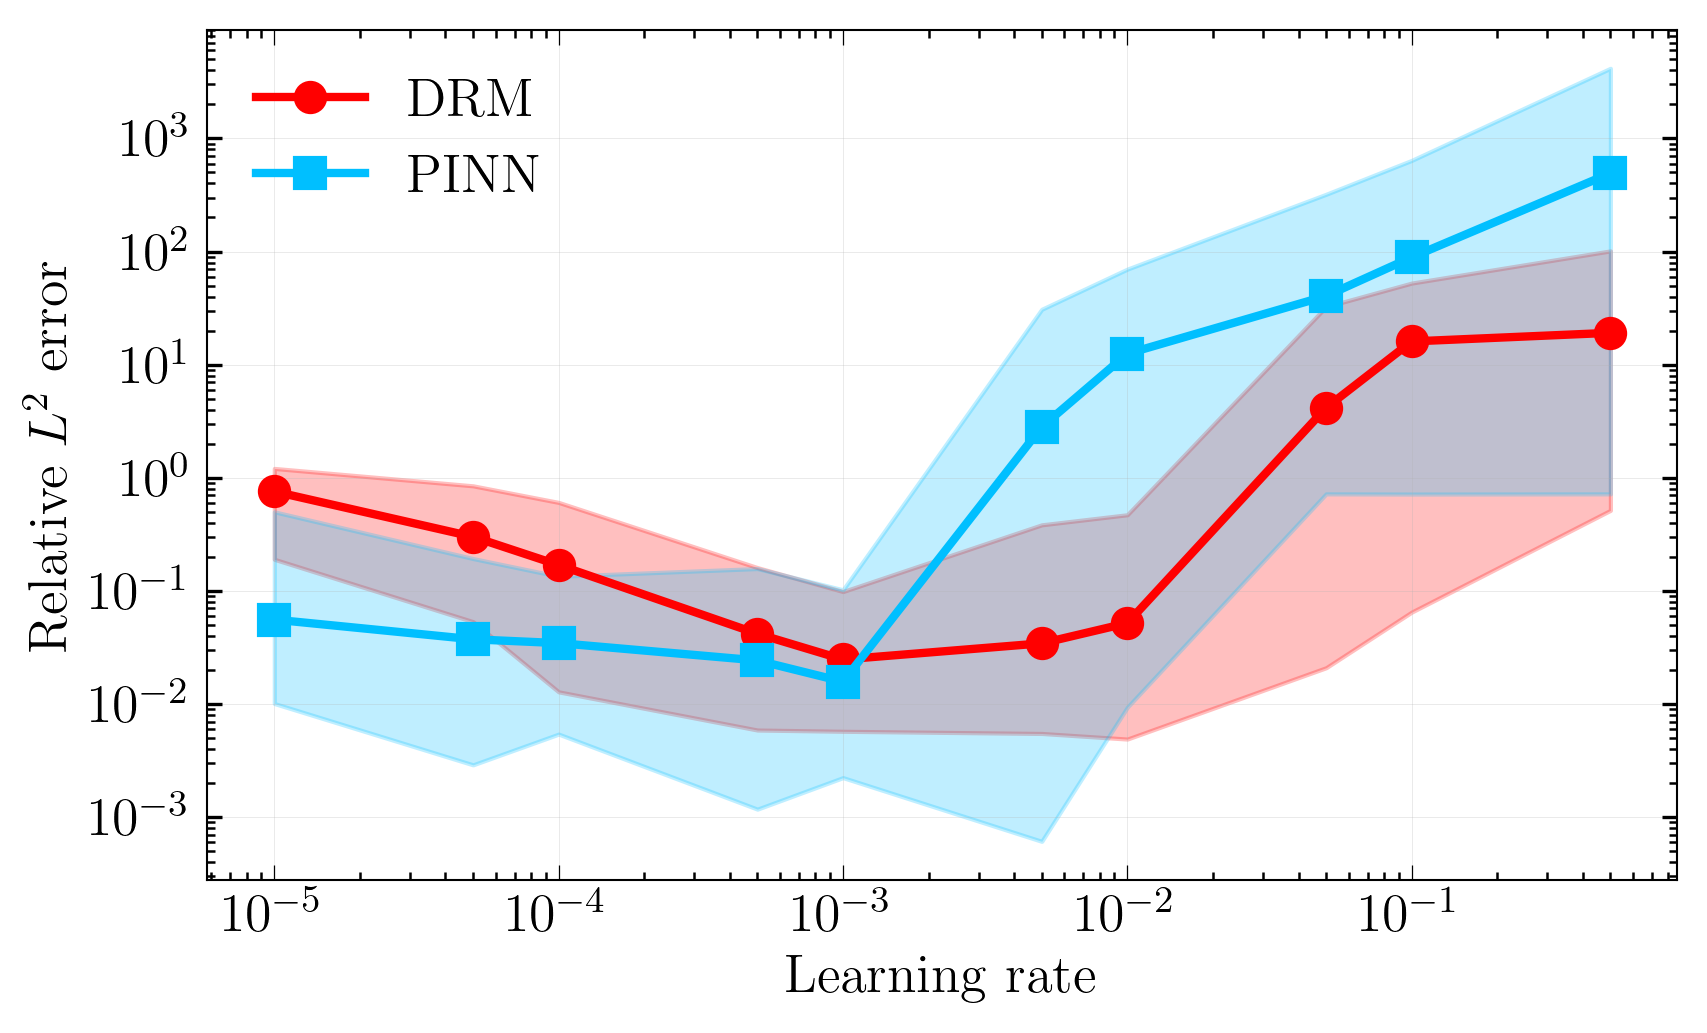

In [127]:
## Collocation Points

# manually resize the text for single plot
mpl.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
})

# Load Deep Ritz results
dr_data = np.load("deepritz_1d_lr_sweep_50seeds_minmax.npz")
dr_lr = dr_data["param_values"]
dr_mean_l2 = dr_data["mean_final_rel_l2_full"]
dr_l2_min = dr_data["min_final_rel_l2_full"]
dr_l2_max = dr_data["max_final_rel_l2_full"]

# Load PINNs results
pinn_data = np.load("pinn_1d_lr_sweep_50seeds_minmax.npz")
pinn_lr = pinn_data["param_values"]
pinn_mean_l2 = pinn_data["mean_final_rel_l2_full"]
pinn_l2_min = pinn_data["min_final_rel_l2_full"]
pinn_l2_max = pinn_data["max_final_rel_l2_full"]

# set x axis
dr_x = dr_lr
pinn_x = pinn_lr

# name file
filename = "lr_sweep"

# plot
fig = plt.figure(figsize=(single_width, single_height))

# data plotting
plt.plot(dr_x, dr_mean_l2, marker="o", linewidth=2, markersize=7, label="DRM", color="red")
plt.fill_between(dr_x, dr_l2_min, dr_l2_max, alpha=0.25, color="red")
plt.plot(pinn_x, pinn_mean_l2, marker="s", linewidth=2, markersize=7, label="PINN", color="deepskyblue")
plt.fill_between(pinn_x, pinn_l2_min, pinn_l2_max, alpha=0.25, color="deepskyblue")

# axis scaling
plt.xscale("log")
plt.yscale("log")

# labels
plt.xlabel("Learning rate")
plt.ylabel("Relative $L^2$ error")

# formatting
plt.grid(True, which="major", alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()

fig.savefig(f"{filename}.png")
fig.savefig(f"{filename}.pdf")
plt.show()